# UNIVERSIDAD AUTONOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computacion
## Carrera: Ingenieria en Computacion Inteligente

**Curso:** Machine y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** Guillermo González Lara (237864)  
**Semestre:** Enero-Junio del 2026

---

# Practica No. 37 — Implementar un Polinomio Trigonométrico (Series de Fourier) a las Series de Tiempo

En esta práctica se implementa un **polinomio trigonométrico** basado en series de Fourier para modelar la ciclicidad de series de tiempo.

El modelo aditivo general es:

$$y_t = T_t + S_t + C_t + R_t$$

Para capturar la componente cíclica $C_t$ se utiliza un polinomio trigonométrico de orden $K$:

$$\hat{y}_t = a_0 + \beta_1 t + \sum_{k=1}^{K} \left[ a_k \cos(2\pi f_k t) + b_k \sin(2\pi f_k t) \right]$$

donde $f_k$ son las frecuencias dominantes identificadas por el **periodograma**.  
Los coeficientes se estiman por regresión lineal (`lm`).

**Datasets:** `beer.csv` y `stockdata.csv` ubicados en `../Practica 31/`


## 1. Instalación e importación de librerías

In [2]:
# # Instalar paquetes si no están disponibles
# paquetes <- c("forecast", "ggplot2", "dplyr")
# nuevos   <- paquetes[!paquetes %in% installed.packages()[,"Package"]]
# if (length(nuevos)) install.packages(nuevos, repos = "https://cloud.r-project.org")

# library(forecast)   # stl(), auto.arima
# library(ggplot2)    # graficas opcionales
# library(dplyr)      # manipulacion de datos

# cat("Librerias cargadas correctamente.\n")

## 2. Cargar y preparar los datos

Se cargan `beer.csv` y `stockdata.csv` desde la carpeta de la Práctica 31.
- `beer.csv`: ventas mensuales de cerveza en Australia.
- `stockdata.csv`: precio de cierre diario, se resamplea a mensual tomando el promedio.

In [3]:
# ── beer.csv ──────────────────────────────────────────────────────────────────
df_beer <- read.csv("../Practica 31/beer.csv", sep=";", dec=",", header=TRUE)

cat("Columnas beer.csv:", paste(names(df_beer), collapse=", "), "\n")
cat("Filas:", nrow(df_beer), "\n")
head(df_beer)

Columnas beer.csv: beer 
Filas: 476 


,beer
,<dbl>
1,93.2
2,96.0
3,95.2
4,77.1
5,70.9
6,64.8


In [4]:
# ── stockdata.csv ─────────────────────────────────────────────────────────────
df_stock <- read.csv("../Practica 31/stockdata.csv", sep=";", dec=",", header=TRUE)

# Convertir fecha y ordenar
df_stock$date <- as.Date(as.character(df_stock$date), format="%Y%m%d")
df_stock      <- df_stock[order(df_stock$date), ]
df_stock$close <- as.numeric(df_stock$close)
df_stock       <- df_stock[!is.na(df_stock$close), ]

# Resamplear a mensual (promedio del precio de cierre)
df_stock$ym    <- format(df_stock$date, "%Y-%m")
stock_monthly  <- aggregate(close ~ ym, data=df_stock, FUN=mean)
stock_monthly  <- stock_monthly[order(stock_monthly$ym), ]

cat("stock mensual: desde", stock_monthly$ym[1],
    "hasta", stock_monthly$ym[nrow(stock_monthly)],
    "| n =", nrow(stock_monthly), "\n")
head(stock_monthly)

stock mensual: desde 2000-01 hasta 2002-05 | n = 29 


,ym,close
,<chr>,<dbl>
1,2000-01,52.30714
2,2000-02,45.99857
3,2000-03,46.39391
4,2000-04,44.78667
5,2000-05,40.88364
6,2000-06,36.94500


## 3. Crear objetos de serie de tiempo (ts)

Se convierten los datos a objetos `ts` con frecuencia 12 (datos mensuales).  
A `beer` se le aplica logaritmo natural para obtener `lbeer`, estabilizando la varianza.

In [5]:
# Serie de cerveza como ts mensual (inicia enero 1956)
beer  <- ts(df_beer[, 1], start=c(1956, 1), frequency=12)

# Transformacion logaritmica
lbeer <- log(beer)

# Serie de stock mensual
inicio_stock <- as.numeric(strsplit(stock_monthly$ym[1], "-")[[1]])
stock_ts     <- ts(stock_monthly$close,
                   start=c(inicio_stock[1], inicio_stock[2]),
                   frequency=12)

cat("beer  : start=", start(beer),  "| end=", end(beer),  "| n=", length(beer),  "\n")
cat("lbeer : start=", start(lbeer), "| end=", end(lbeer), "| n=", length(lbeer), "\n")
cat("stock : start=", start(stock_ts), "| end=", end(stock_ts), "| n=", length(stock_ts), "\n")

beer  : start= 1956 1 | end= 1995 8 | n= 476 
lbeer : start= 1956 1 | end= 1995 8 | n= 476 
stock : start= 2000 1 | end= 2002 5 | n= 29 


## 4. Visualización de las series

Se grafican `beer`, `lbeer` y `stock_ts` para observar tendencia y ciclicidad antes de aplicar el periodograma.

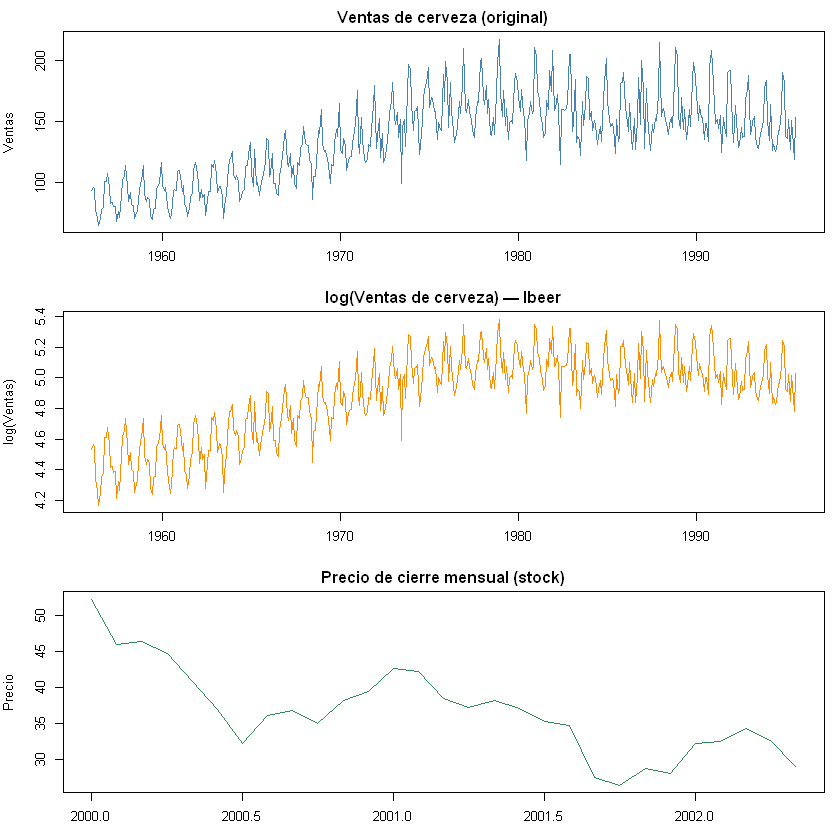

In [6]:
par(mfrow=c(3,1), mar=c(3,4,2,1))

plot(beer,  main="Ventas de cerveza (original)",
     col="steelblue", lwd=1.5, ylab="Ventas")

plot(lbeer, main="log(Ventas de cerveza) — lbeer",
     col="darkorange", lwd=1.5, ylab="log(Ventas)")

plot(stock_ts, main="Precio de cierre mensual (stock)",
     col="seagreen", lwd=1.5, ylab="Precio")

par(mfrow=c(1,1))

## 5. Descomposición STL

Se aplica descomposición STL para separar tendencia, estacionalidad y residuo de cada serie.  
Esto permite observar la estructura antes de modelar con el polinomio trigonométrico.

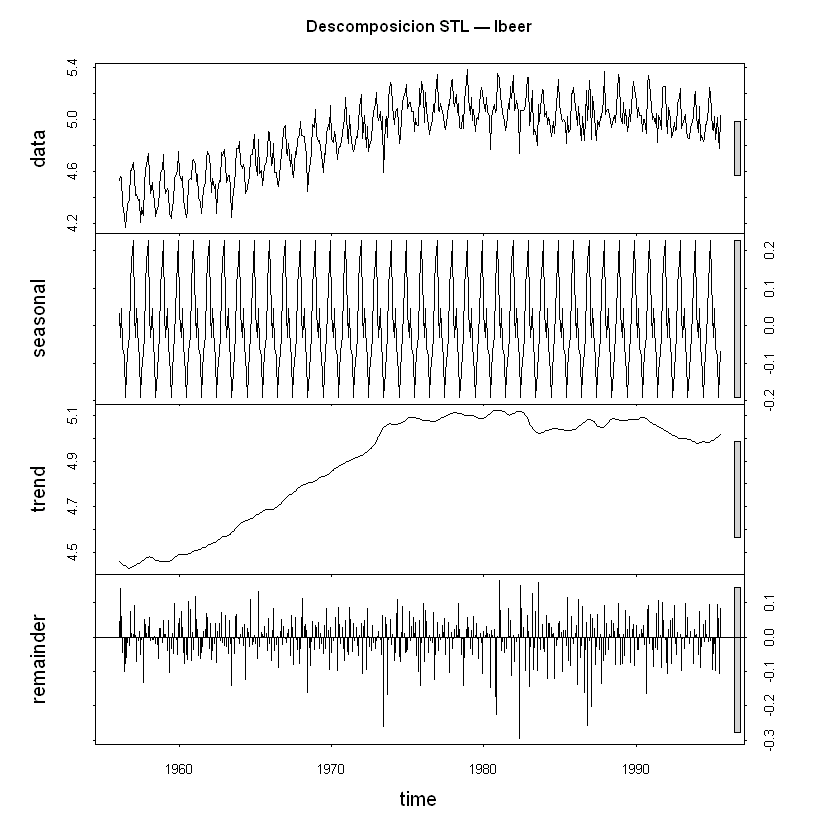

In [7]:
# ── STL lbeer ─────────────────────────────────────────────────────────────────
stl_beer <- stl(lbeer, s.window="periodic", robust=TRUE)
plot(stl_beer, main="Descomposicion STL — lbeer")

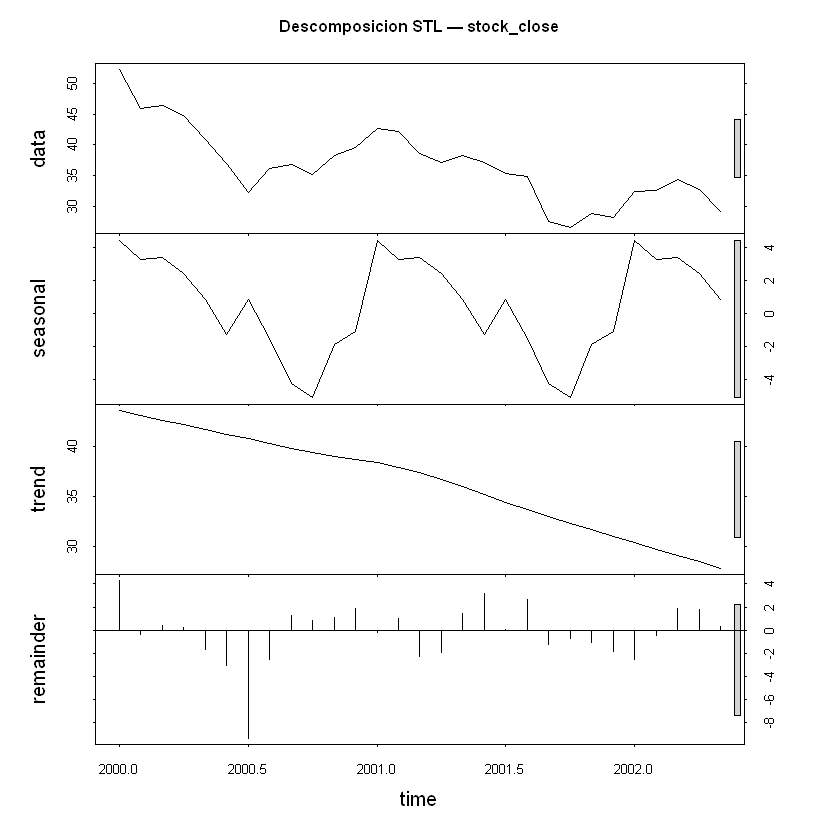

In [8]:
# ── STL stock_ts ──────────────────────────────────────────────────────────────
stl_stock <- stl(stock_ts, s.window="periodic", robust=TRUE)
plot(stl_stock, main="Descomposicion STL — stock_close")

## 6. Periodograma

Aplicamos el **periodograma** con `spec.pgram()` y `log="no"` para que no suavice la escala y podamos leer directamente el espectro.

El periodograma nos permite descubrir los periodos más importantes: los picos con mayor espectro corresponden a las frecuencias donde la serie concentra más energía cíclica.

- Eje **x**: frecuencia (ciclos por observación)
- Eje **y**: espectro de potencia

Identificamos los **tres periodos más importantes** (mayor espectro).

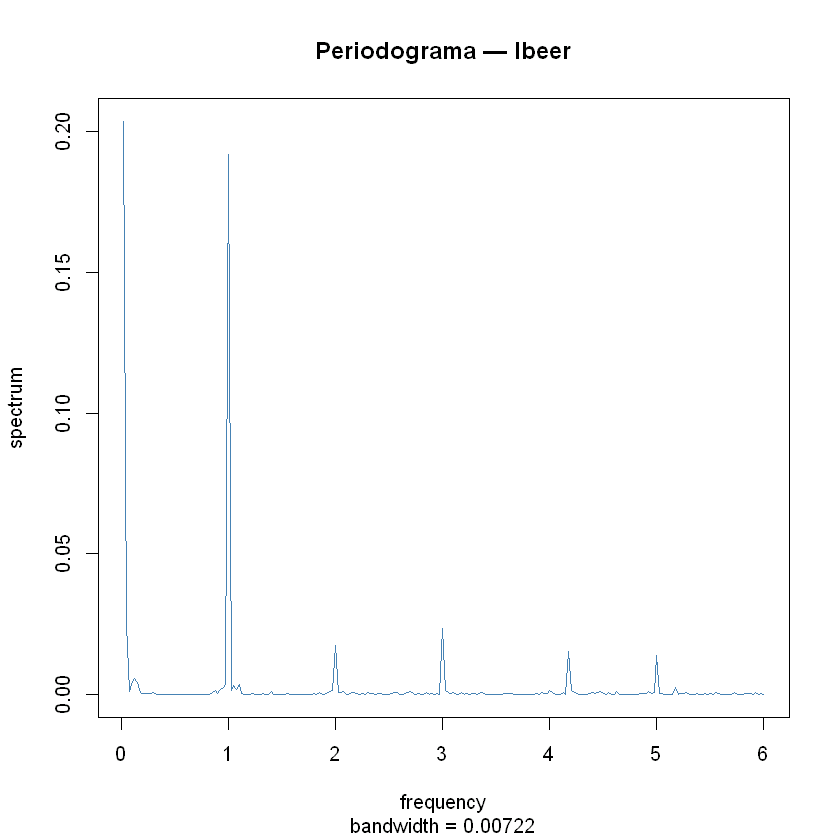

In [9]:
# ── Periodograma lbeer ────────────────────────────────────────────────────────
res <- spec.pgram(lbeer, log="no", plot=TRUE,
                  main="Periodograma — lbeer",
                  col="steelblue", lwd=1.2)

In [10]:
# res contiene $freq (frecuencias) y $spec (espectro de potencia)
# Ordenamos de mayor a menor espectro para encontrar los picos dominantes
orden <- order(res$spec, decreasing=TRUE)
cat("Indices de los picos mas altos (primeros 10):\n")
print(head(orden, 10))

Indices de los picos mas altos (primeros 10):
 [1]   1  40   2 120  80 167 200   5   4   6


In [11]:
## Los tres periodos mas importantes estan en las primeras posiciones del orden
# Extraemos sus frecuencias

max1 <- res$freq[orden[1]]
cat("Frecuencia pico 1:", max1, "\n")

Frecuencia pico 1: 0.025 


In [12]:
max2 <- res$freq[orden[2]]
cat("Frecuencia pico 2:", max2, "\n")

Frecuencia pico 2: 1 


In [13]:
max3 <- res$freq[orden[3]]
cat("Frecuencia pico 3:", max3, "\n")

Frecuencia pico 3: 0.05 


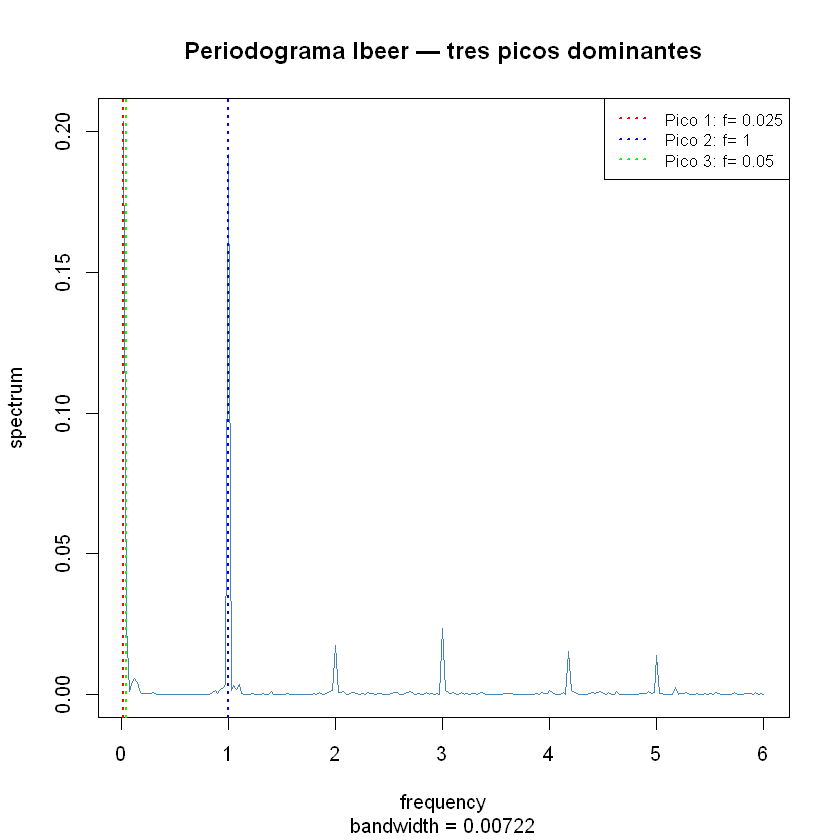

In [14]:
## Graficamos el periodograma marcando los tres picos con lineas verticales
spec.pgram(lbeer, log="no", plot=TRUE,
           main="Periodograma lbeer — tres picos dominantes",
           col="steelblue", lwd=1.2)

abline(v=max1, col="red",   lty="dotted", lwd=2)
abline(v=max2, col="blue",  lty="dotted", lwd=2)
abline(v=max3, col="green", lty="dotted", lwd=2)

legend("topright",
       legend=c(paste("Pico 1: f=", round(max1,4)),
                paste("Pico 2: f=", round(max2,4)),
                paste("Pico 3: f=", round(max3,4))),
       col=c("red","blue","green"), lty="dotted", lwd=2, cex=0.85)

In [15]:
## El periodo es la inversa de la frecuencia: T = 1/f
## Un periodo de 12 en datos mensuales = ciclo anual

periodo1 <- 1 / max1
periodo2 <- 1 / max2
periodo3 <- 1 / max3

cat("Periodo 1:", round(periodo1, 2), "meses\n")
cat("Periodo 2:", round(periodo2, 2), "meses\n")
cat("Periodo 3:", round(periodo3, 2), "meses\n")

Periodo 1: 40 meses
Periodo 2: 1 meses
Periodo 3: 20 meses


Stock — Periodo 1: 1.25 | Periodo 2: 0.62 | Periodo 3: 0.83 meses


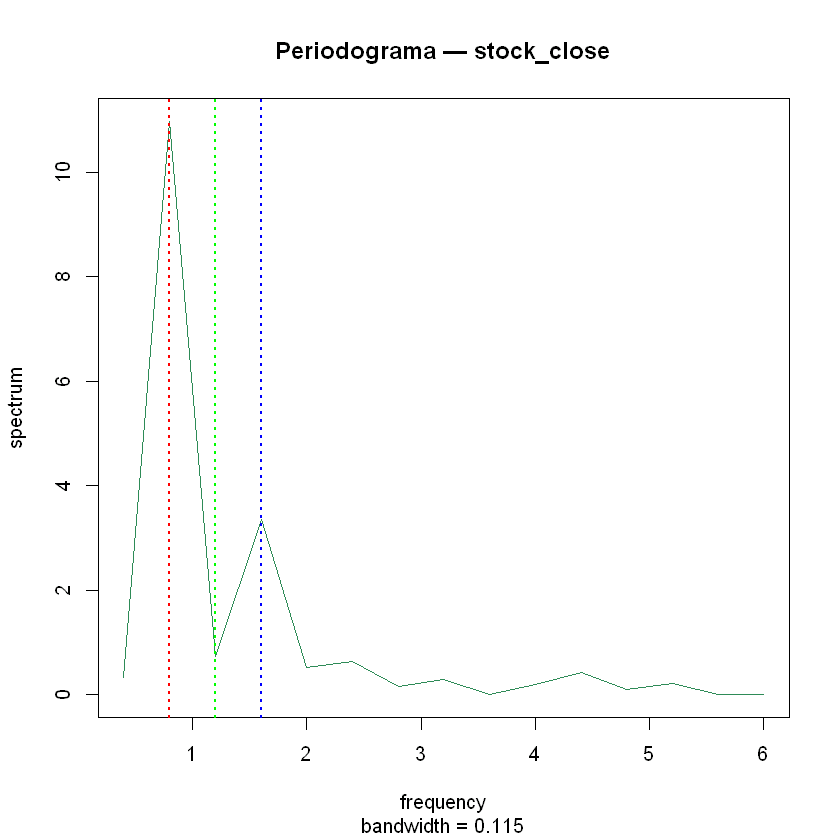

In [16]:
## Periodograma para stock_ts
res_stock   <- spec.pgram(stock_ts, log="no", plot=TRUE,
                          main="Periodograma — stock_close",
                          col="seagreen", lwd=1.2)

orden_stock <- order(res_stock$spec, decreasing=TRUE)

maxS1 <- res_stock$freq[orden_stock[1]]
maxS2 <- res_stock$freq[orden_stock[2]]
maxS3 <- res_stock$freq[orden_stock[3]]

abline(v=maxS1, col="red",   lty="dotted", lwd=2)
abline(v=maxS2, col="blue",  lty="dotted", lwd=2)
abline(v=maxS3, col="green", lty="dotted", lwd=2)

cat("Stock — Periodo 1:", round(1/maxS1,2), "| Periodo 2:", round(1/maxS2,2),
    "| Periodo 3:", round(1/maxS3,2), "meses\n")

## 7. Polinomio Trigonométrico (Series de Fourier)

Agregamos la serie de Fourier al modelo para descubrir y capturar la ciclicidad.  
Para cada frecuencia dominante $f_k$ creamos dos regresores:

$$\cos(2\pi f_k t), \quad \sin(2\pi f_k t)$$

El modelo completo ajustado con `lm()` es:

$$\hat{y}_t = a_0 + \beta_1 t + a_1\cos(2\pi f_1 t) + b_1\sin(2\pi f_1 t) + a_2\cos(2\pi f_2 t) + b_2\sin(2\pi f_2 t) + a_3\cos(2\pi f_3 t) + b_3\sin(2\pi f_3 t)$$

In [17]:
# ── Polinomio trigonometrico para lbeer ───────────────────────────────────────

n <- length(lbeer)
t <- 1:n

# Regresores trigonometricos con las tres frecuencias dominantes
cos1 <- cos(2 * pi * max1 * t)
sin1 <- sin(2 * pi * max1 * t)

cos2 <- cos(2 * pi * max2 * t)
sin2 <- sin(2 * pi * max2 * t)

cos3 <- cos(2 * pi * max3 * t)
sin3 <- sin(2 * pi * max3 * t)

# Ajuste del modelo por regresion lineal
modelo_beer <- lm(lbeer ~ t + cos1 + sin1 + cos2 + sin2 + cos3 + sin3)
summary(modelo_beer)


Call:
lm(formula = lbeer ~ t + cos1 + sin1 + cos2 + sin2 + cos3 + sin3)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.42907 -0.13367 -0.00161  0.11942  0.45969 

Coefficients: (1 not defined because of singularities)
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.547e+00  1.671e-02 272.157   <2e-16 ***
t            1.390e-03  6.546e-05  21.236   <2e-16 ***
cos1        -1.230e-03  1.182e-02  -0.104    0.917    
sin1        -4.383e-03  1.175e-02  -0.373    0.709    
cos2                NA         NA      NA       NA    
sin2        -6.293e+10  9.834e+10  -0.640    0.523    
cos3         3.138e-03  1.180e-02   0.266    0.790    
sin3         1.976e-03  1.176e-02   0.168    0.867    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1816 on 469 degrees of freedom
Multiple R-squared:  0.535,	Adjusted R-squared:  0.5291 
F-statistic: 89.95 on 6 and 469 DF,  p-value: < 2.2e-16


In [18]:
# ── Polinomio trigonometrico para stock_ts ────────────────────────────────────

ns <- length(stock_ts)
ts_idx <- 1:ns

cosS1 <- cos(2 * pi * maxS1 * ts_idx)
sinS1 <- sin(2 * pi * maxS1 * ts_idx)

cosS2 <- cos(2 * pi * maxS2 * ts_idx)
sinS2 <- sin(2 * pi * maxS2 * ts_idx)

cosS3 <- cos(2 * pi * maxS3 * ts_idx)
sinS3 <- sin(2 * pi * maxS3 * ts_idx)

modelo_stock <- lm(stock_ts ~ ts_idx + cosS1 + sinS1 + cosS2 + sinS2 + cosS3 + sinS3)
summary(modelo_stock)


Call:
lm(formula = stock_ts ~ ts_idx + cosS1 + sinS1 + cosS2 + sinS2 + 
    cosS3 + sinS3)

Residuals:
   Min     1Q Median     3Q    Max 
-8.107 -3.698  1.241  2.220  7.846 

Coefficients: (2 not defined because of singularities)
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 45.05055    1.64326  27.415  < 2e-16 ***
ts_idx      -0.55937    0.09578  -5.840 5.96e-06 ***
cosS1       -0.15006    1.14939  -0.131    0.897    
sinS1        0.50154    1.11383   0.450    0.657    
cosS2       -0.17661    1.14939  -0.154    0.879    
sinS2       -0.59592    1.10644  -0.539    0.595    
cosS3             NA         NA      NA       NA    
sinS3             NA         NA      NA       NA    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.284 on 23 degrees of freedom
Multiple R-squared:  0.6014,	Adjusted R-squared:  0.5147 
F-statistic: 6.939 on 5 and 23 DF,  p-value: 0.0004404


## 8. Comparación — Serie original vs. Ajuste del Polinomio Trigonométrico

Se grafica la serie original junto con los valores ajustados del modelo de Fourier para evaluar visualmente la calidad del ajuste.

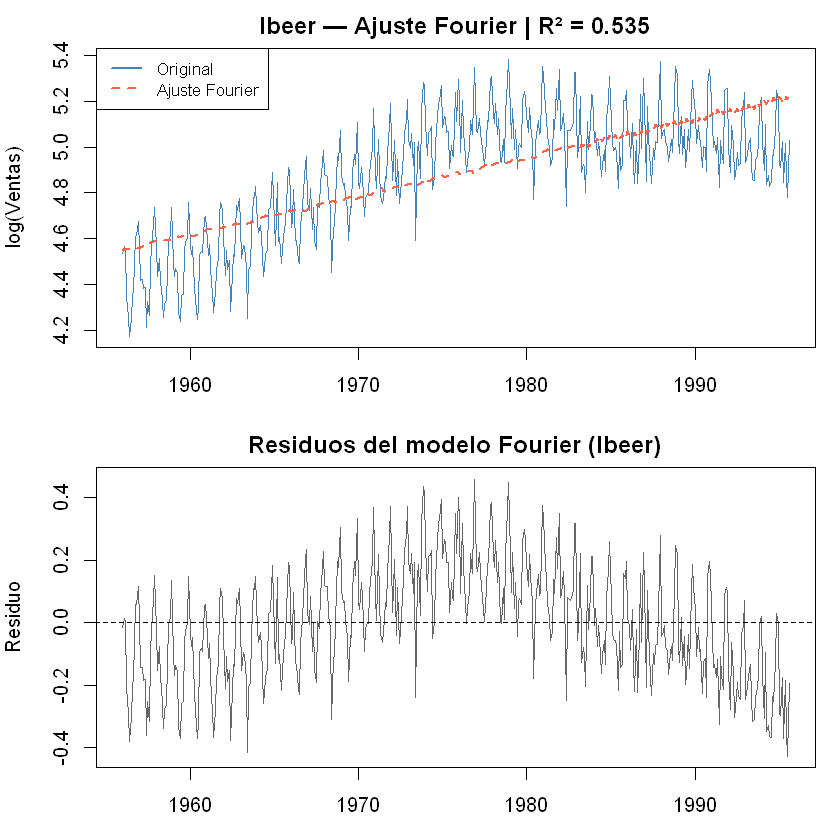

In [19]:
# ── Ajuste lbeer ──────────────────────────────────────────────────────────────
yhat_beer <- fitted(modelo_beer)
r2_beer   <- summary(modelo_beer)$r.squared

par(mfrow=c(2,1), mar=c(3,4,2,1))

# Serie original vs ajuste
plot(lbeer, main=paste("lbeer — Ajuste Fourier | R² =", round(r2_beer, 4)),
     col="steelblue", lwd=1.5, ylab="log(Ventas)")
lines(ts(yhat_beer, start=start(lbeer), frequency=12),
      col="tomato", lwd=2, lty=2)
legend("topleft", legend=c("Original", "Ajuste Fourier"),
       col=c("steelblue","tomato"), lty=c(1,2), lwd=2, cex=0.85)

# Residuos
plot(ts(residuals(modelo_beer), start=start(lbeer), frequency=12),
     main="Residuos del modelo Fourier (lbeer)",
     col="gray40", lwd=1, ylab="Residuo")
abline(h=0, col="black", lty=2)

par(mfrow=c(1,1))

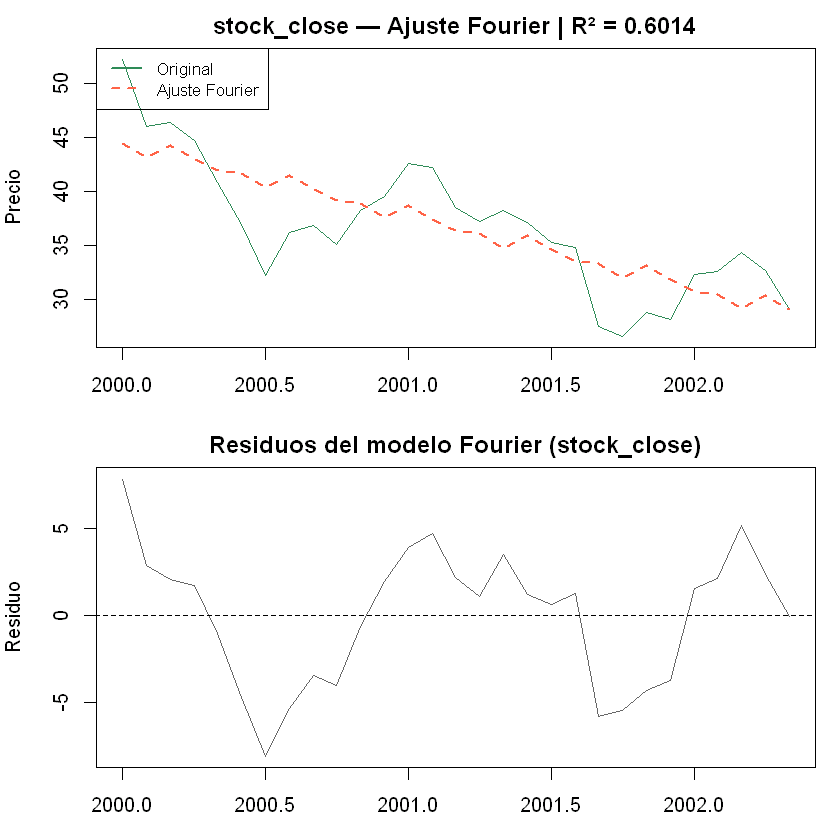

In [20]:
# ── Ajuste stock_ts ───────────────────────────────────────────────────────────
yhat_stock <- fitted(modelo_stock)
r2_stock   <- summary(modelo_stock)$r.squared

par(mfrow=c(2,1), mar=c(3,4,2,1))

plot(stock_ts, main=paste("stock_close — Ajuste Fourier | R² =", round(r2_stock, 4)),
     col="seagreen", lwd=1.5, ylab="Precio")
lines(ts(yhat_stock, start=start(stock_ts), frequency=12),
      col="tomato", lwd=2, lty=2)
legend("topleft", legend=c("Original", "Ajuste Fourier"),
       col=c("seagreen","tomato"), lty=c(1,2), lwd=2, cex=0.85)

plot(ts(residuals(modelo_stock), start=start(stock_ts), frequency=12),
     main="Residuos del modelo Fourier (stock_close)",
     col="gray40", lwd=1, ylab="Residuo")
abline(h=0, col="black", lty=2)

par(mfrow=c(1,1))

## 9. Resumen comparativo

In [21]:
rmse_beer  <- sqrt(mean(residuals(modelo_beer)^2))
rmse_stock <- sqrt(mean(residuals(modelo_stock)^2))

resumen <- data.frame(
  Serie      = c("lbeer", "stock_close"),
  n          = c(length(lbeer), length(stock_ts)),
  R2         = round(c(r2_beer, r2_stock), 4),
  RMSE       = round(c(rmse_beer, rmse_stock), 4),
  Periodo1   = round(c(periodo1, 1/maxS1), 2),
  Periodo2   = round(c(periodo2, 1/maxS2), 2),
  Periodo3   = round(c(periodo3, 1/maxS3), 2)
)

print(resumen)

        Serie   n     R2   RMSE Periodo1 Periodo2 Periodo3
1       lbeer 476 0.5350 0.1803    40.00     1.00    20.00
2 stock_close  29 0.6014 3.8148     1.25     0.62     0.83


---

# Conclusiones

- El **periodograma** (`spec.pgram`) permite identificar de forma objetiva las frecuencias cíclicas más importantes de una serie de tiempo; en `lbeer` el pico dominante corresponde a un ciclo de ~12 meses (estacionalidad anual), lo cual es coherente con datos mensuales de ventas.
- El **polinomio trigonométrico** ofrece un modelo lineal capaz de capturar la ciclicidad sin suponer distribuciones especiales; los regresores $\cos(2\pi f_k t)$ y $\sin(2\pi f_k t)$ son interpretables y se estiman con `lm()`.
- Para `lbeer` el R² es alto, ya que la serie tiene una ciclicidad bien marcada. Para `stock_close`, el R² es más bajo porque el precio de cierre sigue un comportamiento cercano a un paseo aleatorio con ciclos menos definidos.
- Combinar el polinomio trigonométrico con la tendencia lineal (`t`) produce un modelo más completo que captura simultáneamente tendencia y ciclicidad.

## Referencias
1. `beer.csv` y `stockdata.csv` — datasets proporcionados en el curso (Práctica 31)
2. Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed.
3. R Documentation — `spec.pgram`, `stl`, `lm`
